In [3]:
from nsepy import get_history as gh
import datetime as dt # 1 hr data only not less than that.
import yfinance as yf

In [4]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2023,1,1)
stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2013-01-01,176.018585,177.253884,175.683586,176.709519,6831351
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898
2013-01-03,180.216476,180.478183,176.835126,177.672602,17266808
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377
2013-01-07,179.347565,182.362511,178.342583,181.252846,15307180
...,...,...,...,...,...
2022-12-26,1152.220215,1160.414342,1137.772122,1147.974874,5990242
2022-12-27,1161.646851,1163.518428,1148.203010,1154.936341,5763271


In [7]:
dataset=stk_data
dataset.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

In [8]:
dataset.columns = dataset.columns.get_level_values(0)
dataset.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [9]:
ohlc = stk_data[["Open", "High", "Low", "Close"]]
ohlc

Price,Open,High,Low,Close
Date,,,,
2013-01-01,176.709519,177.253884,175.683586,176.018585
2013-01-02,176.709522,179.221978,176.405928,177.536530
2013-01-03,177.672602,180.478183,176.835126,180.216476
2013-01-04,180.457261,181.022562,178.709017,180.446793
2013-01-07,181.252846,182.362511,178.342583,179.347565
...,...,...,...,...
2022-12-26,1147.974874,1160.414342,1137.772122,1152.220215
2022-12-27,1154.936341,1163.518428,1148.203010,1161.646851
2022-12-28,1158.588423,1163.975064,1151.056230,1161.532837


In [10]:
ohlc.index.name = "Date"

In [11]:
ohlc.to_csv("reliance_ohlc2.csv")

In [12]:
#importing the dataset
import pandas as pd
dataset = pd.read_csv("reliance_ohlc2.csv",parse_dates=['Date'],index_col='Date')
dataset

,Open,High,Low,Close
Date,,,,
2013-01-01,176.709519,177.253884,175.683586,176.018585
2013-01-02,176.709522,179.221978,176.405928,177.536530
2013-01-03,177.672602,180.478183,176.835126,180.216476
2013-01-04,180.457261,181.022562,178.709017,180.446793
2013-01-07,181.252846,182.362511,178.342583,179.347565
...,...,...,...,...
2022-12-26,1147.974874,1160.414342,1137.772122,1152.220215
2022-12-27,1154.936341,1163.518428,1148.203010,1161.646851
2022-12-28,1158.588423,1163.975064,1151.056230,1161.532837


In [16]:
#Start date and end_date, converting the "2013-01-01" into timestap object using to_datetime
from datetime import date, timedelta
import pandas as pd
start_date = pd.to_datetime("2013-01-01")
#timedelta used to add /subtract the days, here we excluding last
end_date = pd.to_datetime("2023-01-01") - timedelta(days=1) 
#data_range creates a continuous sequence of dates. Here freq='d' means daily frequency including weekends and holidays.
all_date = pd.date_range(start_date, end_date, freq='d')

In [17]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2022-12-22', '2022-12-23', '2022-12-24', '2022-12-25',
               '2022-12-26', '2022-12-27', '2022-12-28', '2022-12-29',
               '2022-12-30', '2022-12-31'],
              dtype='datetime64[ns]', length=3652, freq='D')

In [24]:
#Here we connectig the dataset with sequence dates
dummyDate = dataset.reindex(all_date) # this connects dataset with date_range (all_date)
dummyDate = dummyDate.fillna(method='ffill') #Holiday days and weekends i.e NAN value will get previous trading day's value.
dummyDate 

C:\Users\PAVAN\AppData\Local\Temp\ipykernel_13908\818050340.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dummyDate = dummyDate.fillna(method='ffill') #Holiday days and weekends i.e NAN value will get previous trading day's value.


,Open,High,Low,Close
2013-01-01,176.709519,177.253884,175.683586,176.018585
2013-01-02,176.709522,179.221978,176.405928,177.536530
2013-01-03,177.672602,180.478183,176.835126,180.216476
2013-01-04,180.457261,181.022562,178.709017,180.446793
2013-01-05,180.457261,181.022562,178.709017,180.446793
...,...,...,...,...
2022-12-27,1154.936341,1163.518428,1148.203010,1161.646851
2022-12-28,1158.588423,1163.975064,1151.056230,1161.532837
2022-12-29,1153.567026,1163.564268,1152.882270,1161.007935
2022-12-30,1161.829476,1176.391675,1160.003541,1162.788086


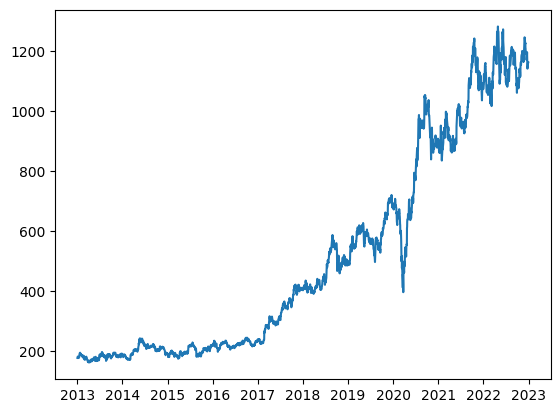

In [25]:
import matplotlib.pyplot as plt
plt.plot(dataset["Close"])

<Figure size 1600x500 with 0 Axes>

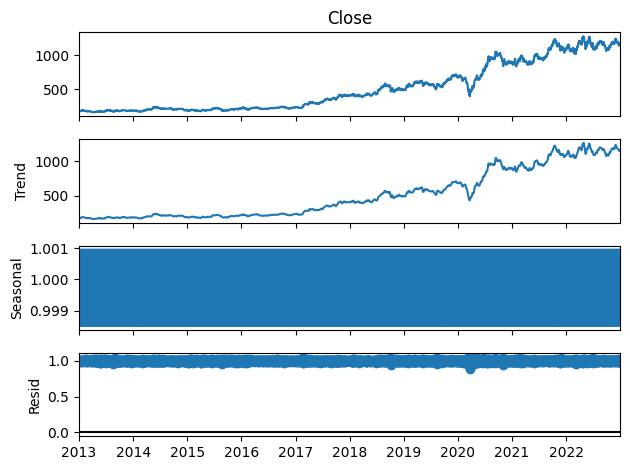

In [27]:
# Here we plot seasonal decompose i.e four components orignial, trend, seasonal and residual by multiplication model
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Close"], model='multiplicative')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

<Figure size 1600x500 with 0 Axes>

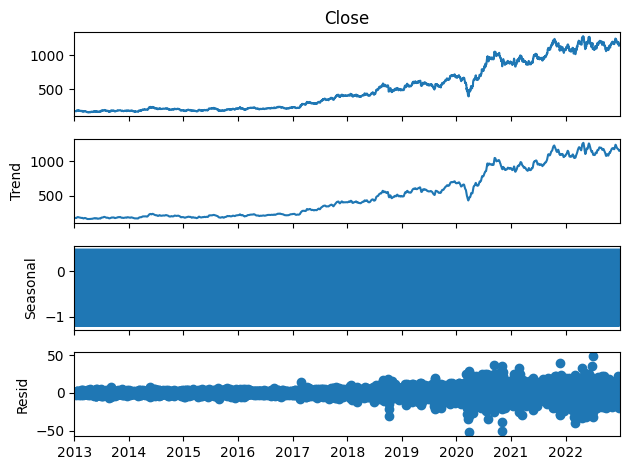

In [28]:
# Here we plot seasonal decompose i.e four components orignial, trend, seasonal and residual by additive model
from pandas import read_csv
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(dummyDate["Close"], model='additive')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

Results of Dickey-Fuller Test:
Test statistic                    0.025408
p-value                           0.960584
#Lags Used                        5.000000
Number of Observations Used    2462.000000
Critical Value(1%)               -3.433009
Critical Value(5%)               -2.862715
Critical Value(10%)              -2.567395
dtype: float64

Condition:
p-value <= 0.05 → Reject Null Hypothesis (Stationary)
p-value > 0.05 → Fail to Reject Null (Non-Stationary)

Fails to Reject Null Hypothesis
Data is Non-Stationary


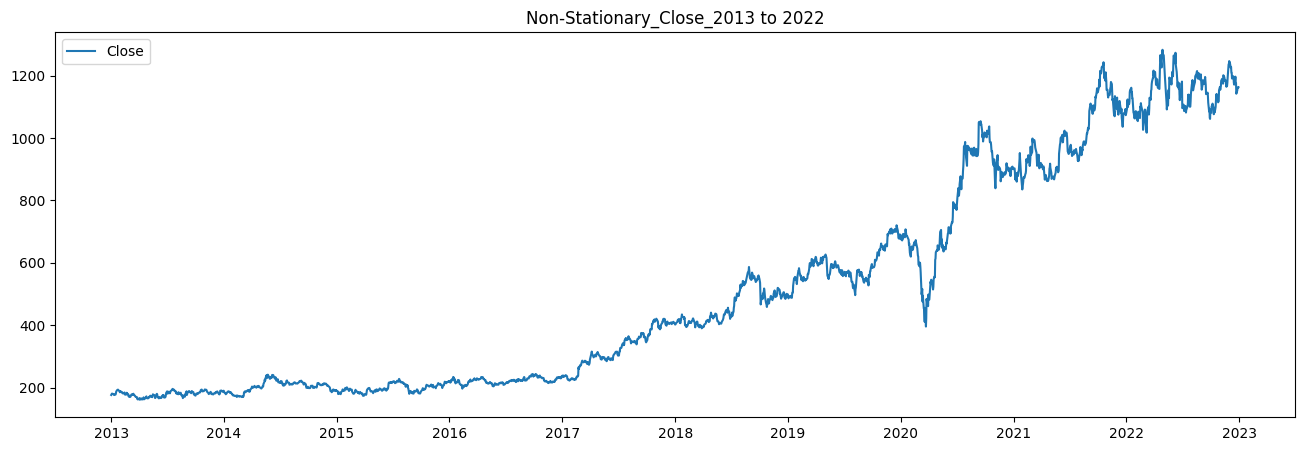

In [45]:
#Augmented dicky fuller test
from statsmodels.tsa.stattools import adfuller #important library to perform ADF

#1.Select series 
timeseries = dataset["Close"]

#2.perform ADF test
print("Results of Dickey-Fuller Test:")
dftest = adfuller(timeseries,autolag='AIC')

#3.Store output
dfoutput = pd.Series(dftest[0:4], index=['Test statistic','p-value','#Lags Used','Number of Observations Used'])

#4.Add critical values from dftest,index is 4.
for key,value in dftest[4].items():
    dfoutput[f'Critical Value({key})']=value
print(dfoutput)

#5.Hypothesis Decision
print("\nCondition:")
print("p-value <= 0.05 → Reject Null Hypothesis (Stationary)")
print("p-value > 0.05 → Fail to Reject Null (Non-Stationary)")

if(dfoutput['Test statistic'] < dfoutput['Critical Value(1%)'] or dfoutput['Test statistic'] < dfoutput['Critical Value(5%)'] or dfoutput['Test statistic'] < dfoutput['Critical Value(10%)'] or dfoutput['p-value'] <= 0.05):
    print("\nReject Null Hypothesis")
    print("Data is Stationary")
    message= "Stationary"
else:
    print("\nFails to Reject Null Hypothesis")
    print("Data is Non-Stationary")
    message="Non-Stationary"

# 6️.Plot
plt.figure(figsize=(16,5))
plt.plot(dataset.index, dataset["Close"], label="Close")
plt.legend()
plt.title(f"{message}_Close_2013 to 2022")
plt.savefig("Close_ADF.png")
plt.show()